# 07 — Leakage-Safe Feature Engineering

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook creates the feature table for one-week-ahead rolling forecasts. Sales features use past weeks only. Current price, calendar event, and SNAP information are allowed because they are known for the forecast week. Model training is not performed here.

## 1. Prediction-time rules

For a target week starting on date `t`:

- `sales_lag_1` uses sales from `t - 1 week`;
- rolling statistics first shift by one week, then summarize past values;
- the target `weekly_units_sold` is never used as its own feature;
- event, SNAP, and price fields for week `t` are known planning inputs;
- validation and test are evaluated as rolling one-week-ahead forecasts, so an actual earlier week may be used only after that week has occurred;
- the current-week outlier flag is excluded because it is calculated from current sales.

In [1]:
from pathlib import Path
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as pads
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "m5_foods_weekly").exists():
            return candidate.resolve()
    raise FileNotFoundError("Processed FOODS data was not found. Run notebooks 01 and 02 first.")

PROJECT_ROOT = find_project_root()
SOURCE_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_weekly"
FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_features"
REPORT_DIR = PROJECT_ROOT / "reports"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
for old_file in FEATURE_DIR.glob("*.parquet"):
    old_file.unlink()

source_dataset = pads.dataset(SOURCE_DIR, format="parquet")
source_columns = [
    "item_id", "dept_id", "store_id", "state_id",
    "week_start", "week_end", "weekly_units_sold",
    "sell_price_mean", "event_days", "snap_days", "dataset_split",
]
source_table = source_dataset.to_table(columns=source_columns)
frame = source_table.to_pandas(categories=["item_id", "dept_id", "store_id", "state_id", "dataset_split"])
frame = frame.sort_values(["store_id", "item_id", "week_start"]).reset_index(drop=True)

print("Source rows:", f"{len(frame):,}")
print("Source columns:", len(frame.columns))

Source rows: 3,118,862
Source columns: 11


## 2. Confirm a continuous weekly index

`groupby().shift()` represents an exact weekly lag only if consecutive rows for each store-product series are seven days apart. The cleaning output is checked before any feature is created.

In [2]:
group_keys = ["store_id", "item_id"]
week_gap_days = frame.groupby(group_keys, observed=True, sort=False)["week_start"].diff().dt.days
non_first_gaps = week_gap_days.dropna()

gap_summary = pd.DataFrame([
    {"metric": "non_first_rows", "value": len(non_first_gaps)},
    {"metric": "exact_7_day_gaps", "value": int(non_first_gaps.eq(7).sum())},
    {"metric": "gaps_over_7_days", "value": int(non_first_gaps.gt(7).sum())},
    {"metric": "maximum_gap_days", "value": int(non_first_gaps.max())},
])
display(gap_summary)
assert non_first_gaps.eq(7).all(), "Date-aware joins are required because the weekly index has gaps."

,metric,value
0,non_first_rows,3104492
1,exact_7_day_gaps,3104492
2,gaps_over_7_days,0
3,maximum_gap_days,7


## 3. Create past-only sales and price features

Every rolling calculation starts with `shift(1)`. This is the central leakage-prevention rule.

In [3]:
def add_past_features(data):
    data = data.copy()
    grouped = data.groupby(group_keys, observed=True, sort=False)

    for lag in [1, 2, 4, 8]:
        data[f"sales_lag_{lag}"] = grouped["weekly_units_sold"].shift(lag).astype("float32")

    data["_past_sales"] = grouped["weekly_units_sold"].shift(1).astype("float32")
    past_grouped = data.groupby(group_keys, observed=True, sort=False)["_past_sales"]
    past_zero = data["_past_sales"].eq(0).astype("float32")
    past_zero_grouped = past_zero.groupby([data["store_id"], data["item_id"]], observed=True, sort=False)

    for window in [4, 8]:
        data[f"sales_roll_mean_{window}"] = past_grouped.rolling(window, min_periods=window).mean().reset_index(level=[0, 1], drop=True).astype("float32")
        data[f"sales_roll_std_{window}"] = past_grouped.rolling(window, min_periods=window).std(ddof=0).reset_index(level=[0, 1], drop=True).astype("float32")

    data["zero_weeks_last_4"] = past_zero_grouped.rolling(4, min_periods=4).sum().reset_index(level=[0, 1], drop=True).astype("float32")
    data["price_lag_1"] = grouped["sell_price_mean"].shift(1).astype("float32")
    data["price_change_pct"] = ((data["sell_price_mean"] - data["price_lag_1"]) / data["price_lag_1"]).astype("float32")
    return data.drop(columns="_past_sales")

frame = add_past_features(frame)

frame["year"] = frame["week_start"].dt.year.astype("int16")
frame["month"] = frame["week_start"].dt.month.astype("int8")
frame["week_of_year"] = frame["week_start"].dt.isocalendar().week.astype("int16")
frame["quarter"] = frame["week_start"].dt.quarter.astype("int8")
frame["has_event"] = frame["event_days"].gt(0).astype("int8")
frame["has_snap"] = frame["snap_days"].gt(0).astype("int8")

display(frame.head(12))

,item_id,dept_id,store_id,state_id,week_start,week_end,weekly_units_sold,sell_price_mean,event_days,snap_days,dataset_split,sales_lag_1,sales_lag_2,sales_lag_4,sales_lag_8,sales_roll_mean_4,sales_roll_std_4,sales_roll_mean_8,sales_roll_std_8,zero_weeks_last_4,price_lag_1,price_change_pct,year,month,week_of_year,quarter,has_event,has_snap
0,FOODS_1_001,FOODS_1,CA_1,CA,2011-01-31,2011-02-06,9,2.000,1,6,train,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,1,5,1,1,1
1,FOODS_1_001,FOODS_1,CA_1,CA,2011-02-07,2011-02-13,7,2.000,0,4,train,9.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,0.000,2011,2,6,1,0,1
2,FOODS_1_001,FOODS_1,CA_1,CA,2011-02-14,2011-02-20,10,2.000,1,0,train,7.000,9.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,0.000,2011,2,7,1,1,0
3,FOODS_1_001,FOODS_1,CA_1,CA,2011-02-21,2011-02-27,14,2.000,1,0,train,10.000,7.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000,2.000,0.000,2011,2,8,1,1,0
4,FOODS_1_001,FOODS_1,CA_1,CA,2011-02-28,2011-03-06,16,2.000,0,6,train,14.000,10.000,9.000,NaN,10.000,2.550,NaN,NaN,0.000,2.000,0.000,2011,2,9,1,0,1
5,FOODS_1_001,FOODS_1,CA_1,CA,2011-03-07,2011-03-13,12,2.000,1,4,train,16.000,14.000,7.000,NaN,11.750,3.491,NaN,NaN,0.000,2.000,0.000,2011,3,10,1,1,1
6,FOODS_1_001,FOODS_1,CA_1,CA,2011-03-14,2011-03-20,3,2.000,3,0,train,12.000,16.000,10.000,NaN,13.000,2.236,NaN,NaN,0.000,2.000,0.000,2011,3,11,1,1,0
7,FOODS_1_001,FOODS_1,CA_1,CA,2011-03-21,2011-03-27,8,2.000,0,0,train,3.000,12.000,14.000,NaN,11.250,4.969,NaN,NaN,0.000,2.000,0.000,2011,3,12,1,0,0
8,FOODS_1_001,FOODS_1,CA_1,CA,2011-03-28,2011-04-03,1,2.000,0,3,train,8.000,3.000,16.000,9.000,9.750,4.815,9.875,3.855,0.000,2.000,0.000,2011,3,13,1,0,1
9,FOODS_1_001,FOODS_1,CA_1,CA,2011-04-04,2011-04-10,8,2.000,0,7,train,1.000,8.000,12.000,7.000,6.000,4.301,8.875,4.859,0.000,2.000,0.000,2011,4,14,2,0,1


## 4. Define the approved feature set

The target and split columns remain in the saved table but are not features. Current-week sales-derived fields, including the outlier flag, are intentionally absent.

In [4]:
categorical_features = ["item_id", "dept_id", "store_id", "state_id"]
numeric_features = [
    "sales_lag_1", "sales_lag_2", "sales_lag_4", "sales_lag_8",
    "sales_roll_mean_4", "sales_roll_std_4",
    "sales_roll_mean_8", "sales_roll_std_8",
    "zero_weeks_last_4",
    "sell_price_mean", "price_lag_1", "price_change_pct",
    "year", "month", "week_of_year", "quarter",
    "event_days", "has_event", "snap_days", "has_snap",
]
target_column = "weekly_units_sold"
metadata_columns = ["week_start", "week_end", "dataset_split"]
approved_columns = metadata_columns + categorical_features + numeric_features + [target_column]

feature_definitions = pd.DataFrame([
    {"feature": "sales_lag_1/2/4/8", "source": "past sales", "rule": "group shift by exact weeks", "known_at_prediction": True},
    {"feature": "sales_roll_mean/std_4/8", "source": "past sales", "rule": "shift(1) before rolling", "known_at_prediction": True},
    {"feature": "zero_weeks_last_4", "source": "past sales", "rule": "zeros after shift(1), rolling 4", "known_at_prediction": True},
    {"feature": "sell_price_mean", "source": "known weekly price", "rule": "current forecast-week input", "known_at_prediction": True},
    {"feature": "price_lag_1/change_pct", "source": "price", "rule": "current known price versus previous price", "known_at_prediction": True},
    {"feature": "year/month/week/quarter", "source": "calendar", "rule": "derived from forecast week", "known_at_prediction": True},
    {"feature": "event_days/has_event", "source": "calendar", "rule": "known event calendar", "known_at_prediction": True},
    {"feature": "snap_days/has_snap", "source": "calendar", "rule": "known SNAP calendar", "known_at_prediction": True},
    {"feature": "has_sales_outlier", "source": "current sales", "rule": "EXCLUDED: unavailable at prediction time", "known_at_prediction": False},
])
display(feature_definitions)

,feature,source,rule,known_at_prediction
0,sales_lag_1/2/4/8,past sales,group shift by exact weeks,True
1,sales_roll_mean/std_4/8,past sales,shift(1) before rolling,True
2,zero_weeks_last_4,past sales,"zeros after shift(1), rolling 4",True
3,sell_price_mean,known weekly price,current forecast-week input,True
4,price_lag_1/change_pct,price,current known price versus previous price,True
5,year/month/week/quarter,calendar,derived from forecast week,True
6,event_days/has_event,calendar,known event calendar,True
7,snap_days/has_snap,calendar,known SNAP calendar,True
8,has_sales_outlier,current sales,EXCLUDED: unavailable at prediction time,False


## 5. Warm-up rows and model-ready table

The first eight active weeks of each series cannot have an eight-week lag. They are excluded from the model-ready feature table, with counts recorded by split.

In [5]:
required_feature_columns = categorical_features + numeric_features
missing_before = frame[numeric_features].isna().sum().rename("missing_rows").reset_index().rename(columns={"index": "feature"})
rows_before = len(frame)
split_before = frame["dataset_split"].astype(str).value_counts().to_dict()

feature_table = frame.dropna(subset=numeric_features).loc[:, approved_columns].copy()
feature_table["dataset_split"] = feature_table["dataset_split"].astype(str)
feature_table = feature_table.sort_values(["week_start", "store_id", "item_id"]).reset_index(drop=True)
split_after = feature_table["dataset_split"].value_counts().to_dict()

split_summary = pd.DataFrame([
    {
        "split": split_name,
        "rows_before": split_before.get(split_name, 0),
        "rows_after": split_after.get(split_name, 0),
        "warmup_rows_removed": split_before.get(split_name, 0) - split_after.get(split_name, 0),
    }
    for split_name in ["train", "validation", "test"]
])

display(missing_before)
display(split_summary)
display(feature_table.head(10))

,feature,missing_rows
0,sales_lag_1,14370
1,sales_lag_2,28740
2,sales_lag_4,57480
3,sales_lag_8,114960
4,sales_roll_mean_4,57480
5,sales_roll_std_4,57480
6,sales_roll_mean_8,114960
7,sales_roll_std_8,114960
8,zero_weeks_last_4,43110
9,sell_price_mean,0


,split,rows_before,rows_after,warmup_rows_removed
0,train,3003902,2888944,114958
1,validation,57480,57478,2
2,test,57480,57480,0


,week_start,week_end,dataset_split,item_id,dept_id,store_id,state_id,sales_lag_1,sales_lag_2,sales_lag_4,sales_lag_8,sales_roll_mean_4,sales_roll_std_4,sales_roll_mean_8,sales_roll_std_8,zero_weeks_last_4,sell_price_mean,price_lag_1,price_change_pct,year,month,week_of_year,quarter,event_days,has_event,snap_days,has_snap,weekly_units_sold
0,2011-03-28,2011-04-03,train,FOODS_1_001,FOODS_1,CA_1,CA,8.000,3.000,16.000,9.000,9.750,4.815,9.875,3.855,0.000,2.000,2.000,0.000,2011,3,13,1,0,0,3,1,1
1,2011-03-28,2011-04-03,train,FOODS_1_002,FOODS_1,CA_1,CA,2.000,3.000,7.000,3.000,3.000,2.550,2.625,2.288,1.000,7.880,7.880,0.000,2011,3,13,1,0,0,3,1,3
2,2011-03-28,2011-04-03,train,FOODS_1_003,FOODS_1,CA_1,CA,5.000,10.000,9.000,7.000,6.500,3.202,6.500,2.398,0.000,2.880,2.880,0.000,2011,3,13,1,0,0,3,1,7
3,2011-03-28,2011-04-03,train,FOODS_1_005,FOODS_1,CA_1,CA,12.000,12.000,11.000,12.000,11.750,0.433,15.000,8.456,0.000,2.940,2.940,0.000,2011,3,13,1,0,0,3,1,10
4,2011-03-28,2011-04-03,train,FOODS_1_006,FOODS_1,CA_1,CA,19.000,13.000,30.000,24.000,21.750,6.379,23.375,9.873,0.000,1.970,1.970,0.000,2011,3,13,1,0,0,3,1,8
5,2011-03-28,2011-04-03,train,FOODS_1_011,FOODS_1,CA_1,CA,3.000,0.000,0.000,3.000,2.750,3.269,3.625,3.120,2.000,2.280,2.280,0.000,2011,3,13,1,0,0,3,1,0
6,2011-03-28,2011-04-03,train,FOODS_1_013,FOODS_1,CA_1,CA,17.000,9.000,19.000,11.000,13.000,5.099,11.750,4.893,0.000,1.250,1.250,0.000,2011,3,13,1,0,0,3,1,13
7,2011-03-28,2011-04-03,train,FOODS_1_016,FOODS_1,CA_1,CA,5.000,7.000,8.000,10.000,8.500,3.354,8.250,3.152,0.000,1.960,1.960,0.000,2011,3,13,1,0,0,3,1,3
8,2011-03-28,2011-04-03,train,FOODS_1_018,FOODS_1,CA_1,CA,44.000,108.000,32.000,33.000,48.250,36.718,44.125,27.429,0.000,1.000,1.000,0.000,2011,3,13,1,0,0,3,1,20
9,2011-03-28,2011-04-03,train,FOODS_1_019,FOODS_1,CA_1,CA,44.000,71.000,50.000,37.000,55.500,10.062,50.875,10.337,0.000,0.970,0.970,0.000,2011,3,13,1,0,0,3,1,63


## 6. Leakage tests

A sentinel test changes a target value and recomputes a small series. Features for that same week must remain unchanged; only later weeks are allowed to react. Additional checks verify exact lags, split order, feature names, nulls, and keys.

In [6]:
sample_keys = frame[group_keys].drop_duplicates().iloc[0]
sample_mask = frame["store_id"].eq(sample_keys["store_id"]) & frame["item_id"].eq(sample_keys["item_id"])
sentinel_source = frame.loc[sample_mask, source_columns].copy().reset_index(drop=True)
sentinel_position = min(20, len(sentinel_source) - 2)
sentinel_original = add_past_features(sentinel_source)
sentinel_changed_source = sentinel_source.copy()
sentinel_changed_source.loc[sentinel_position, "weekly_units_sold"] += 100_000
sentinel_changed = add_past_features(sentinel_changed_source)
past_feature_names = [
    "sales_lag_1", "sales_lag_2", "sales_lag_4", "sales_lag_8",
    "sales_roll_mean_4", "sales_roll_std_4", "sales_roll_mean_8",
    "sales_roll_std_8", "zero_weeks_last_4",
]
sentinel_same_week_unchanged = sentinel_original.loc[sentinel_position, past_feature_names].equals(
    sentinel_changed.loc[sentinel_position, past_feature_names]
)

duplicate_keys = int(feature_table.duplicated(["store_id", "item_id", "week_start"]).sum())
required_nulls = int(feature_table[approved_columns].isna().sum().sum())
split_dates = feature_table.groupby("dataset_split")["week_start"].agg(["min", "max"])
exact_lag_1_sample = frame.loc[sample_mask, "sales_lag_1"].reset_index(drop=True).equals(
    sentinel_source["weekly_units_sold"].shift(1).astype("float32")
)

leakage_checks = pd.DataFrame([
    {"check": "continuous weekly index", "status": "PASS" if non_first_gaps.eq(7).all() else "FAIL", "details": f"{len(non_first_gaps):,} exact weekly gaps"},
    {"check": "same-week sentinel target does not change features", "status": "PASS" if sentinel_same_week_unchanged else "FAIL", "details": f"series position {sentinel_position}"},
    {"check": "lag 1 equals previous target on sample series", "status": "PASS" if exact_lag_1_sample else "FAIL", "details": "exact shift(1) comparison"},
    {"check": "target excluded from feature list", "status": "PASS" if target_column not in required_feature_columns else "FAIL", "details": target_column},
    {"check": "current sales outlier flag excluded", "status": "PASS" if "has_sales_outlier" not in approved_columns else "FAIL", "details": "unavailable at prediction time"},
    {"check": "chronological split order", "status": "PASS" if split_dates.loc["train", "max"] < split_dates.loc["validation", "min"] < split_dates.loc["test", "min"] else "FAIL", "details": "train < validation < test"},
    {"check": "duplicate feature keys", "status": "PASS" if duplicate_keys == 0 else "FAIL", "details": str(duplicate_keys)},
    {"check": "required feature nulls", "status": "PASS" if required_nulls == 0 else "FAIL", "details": str(required_nulls)},
])
display(leakage_checks)
assert leakage_checks["status"].eq("PASS").all()

,check,status,details
0,continuous weekly index,PASS,"3,104,492 exact weekly gaps"
1,same-week sentinel target does not change feat...,PASS,series position 20
2,lag 1 equals previous target on sample series,PASS,exact shift(1) comparison
3,target excluded from feature list,PASS,weekly_units_sold
4,current sales outlier flag excluded,PASS,unavailable at prediction time
5,chronological split order,PASS,train < validation < test
6,duplicate feature keys,PASS,0
7,required feature nulls,PASS,0


## 7. Save split Parquet files and reports

Train, validation, and test are written separately. Generated Parquet files remain local; only definitions and verification reports are committed.

In [7]:
for split_name in ["train", "validation", "test"]:
    split_frame = feature_table.loc[feature_table["dataset_split"].eq(split_name)].copy()
    split_frame.to_parquet(FEATURE_DIR / f"{split_name}.parquet", index=False)

saved_dataset = pads.dataset(FEATURE_DIR, format="parquet")
saved_rows = saved_dataset.count_rows()
feature_summary = pd.DataFrame([
    {"metric": "source_rows", "value": rows_before},
    {"metric": "model_ready_feature_rows", "value": len(feature_table)},
    {"metric": "warmup_rows_removed", "value": rows_before - len(feature_table)},
    {"metric": "categorical_features", "value": len(categorical_features)},
    {"metric": "numeric_features", "value": len(numeric_features)},
    {"metric": "duplicate_keys", "value": duplicate_keys},
    {"metric": "required_nulls", "value": required_nulls},
    {"metric": "saved_rows_verified", "value": saved_rows},
])

assert saved_rows == len(feature_table)
assert set(split_after) == {"train", "validation", "test"}
assert 0 < split_after["validation"] <= split_before["validation"]
assert 0 < split_after["test"] <= split_before["test"]

feature_definitions.to_csv(REPORT_DIR / "feature_definitions.csv", index=False)
missing_before.to_csv(REPORT_DIR / "feature_missing_before_warmup.csv", index=False)
split_summary.to_csv(REPORT_DIR / "feature_split_summary.csv", index=False)
leakage_checks.to_csv(REPORT_DIR / "leakage_checks.csv", index=False)
feature_summary.to_csv(REPORT_DIR / "feature_summary.csv", index=False)

display(feature_summary)
print("Saved feature rows verified:", f"{saved_rows:,}")
print("Feature folder:", FEATURE_DIR)

,metric,value
0,source_rows,3118862
1,model_ready_feature_rows,3003902
2,warmup_rows_removed,114960
3,categorical_features,4
4,numeric_features,20
5,duplicate_keys,0
6,required_nulls,0
7,saved_rows_verified,3003902


Saved feature rows verified: 3,003,902
Feature folder: F:\7) AI-ML_Fundamental_Project\Git_Desktop\retail-demand-forecasting\data\processed\m5_foods_features


## 8. Visual verification

The first chart shows expected warm-up missing values before removal. The second confirms the final split sizes.

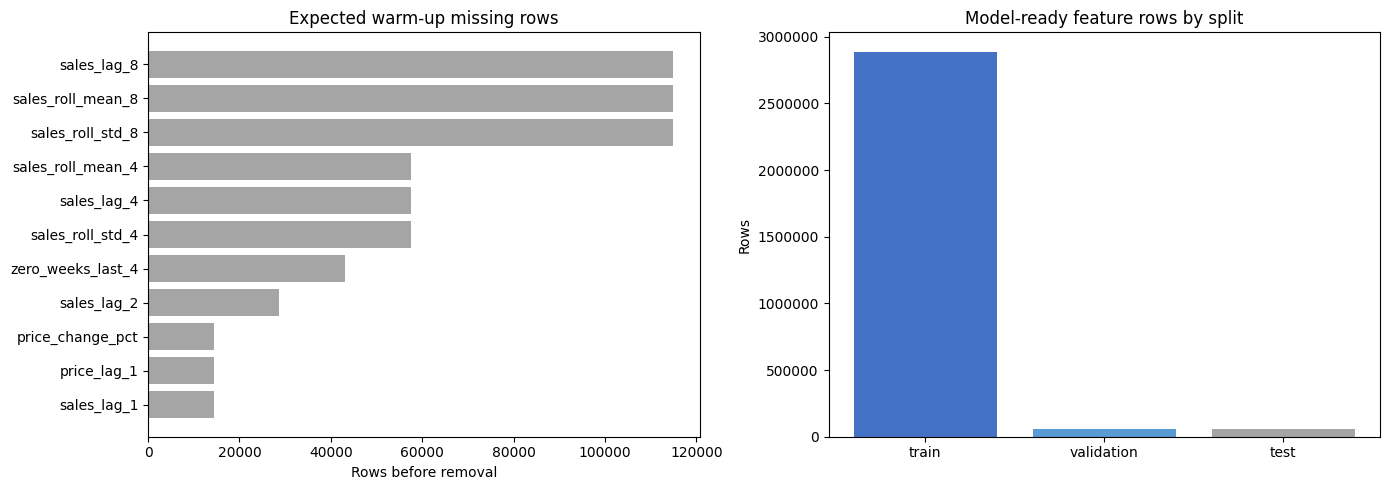

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_plot = missing_before.loc[missing_before["missing_rows"].gt(0)].sort_values("missing_rows")
axes[0].barh(missing_plot["feature"], missing_plot["missing_rows"], color="#A5A5A5")
axes[0].set_title("Expected warm-up missing rows")
axes[0].set_xlabel("Rows before removal")

axes[1].bar(split_summary["split"], split_summary["rows_after"], color=["#4472C4", "#5B9BD5", "#A5A5A5"])
axes[1].set_title("Model-ready feature rows by split")
axes[1].set_ylabel("Rows")
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

## 9. Result

The C3 data stage is complete: raw audit, cleaning, chronological split, EDA, and past-only features are reproducible. The next course stage is a simple baseline and MLflow experiment tracking. Model training must start only after reviewing this feature report.